# Conditional Distributions for the 5-Node DAG

DAG structure:

$$
1 \rightarrow 2,\quad
1 \rightarrow 3,\quad
2 \rightarrow 4,\quad
3 \rightarrow 4,\quad
4 \rightarrow 5.
$$

---


In [3]:
!uv pip install networkx matplotlib seaborn pandas

Using Python 3.13.5 environment at: /home/musel/Documents/github/graph-learning/.venv
Resolved 16 packages in 755ms                                        
Installed 4 packages in 71ms                                
 + pandas==2.3.3
 + pytz==2025.2
 + seaborn==0.13.2
 + tzdata==2025.2


In [4]:
# If needed, install these (run once):
# !pip install networkx matplotlib seaborn pandas

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


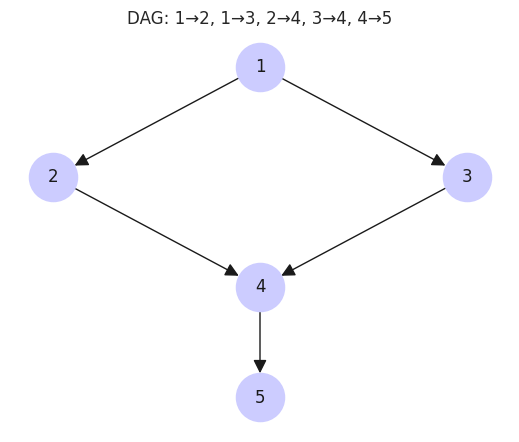

In [21]:
# Define the DAG
G = nx.DiGraph()
G.add_nodes_from([1, 2, 3, 4, 5])
G.add_edges_from([
    (1, 2),
    (1, 3),
    (2, 4),
    (3, 4),
    (4, 5),
])

# Draw the DAG
plt.figure(figsize=(5, 4))

# A manual layout to look like the graph structure
pos = {
    1: (0, 1),
    2: (-1, 0),
    3: (1, 0),
    4: (0, -1),
    5: (0, -2),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1200,
    arrowsize=20,
    node_color="#ccccff",
    font_size=12
)

plt.title("DAG: 1→2, 1→3, 2→4, 3→4, 4→5")
plt.axis("off")
plt.show()



## Bernoulli Bayesian Network

All variables \(X_i \in \{0,1\}\).

Factorization:

$$
p(x_1,x_2,x_3,x_4,x_5)
= p(x_1)\,p(x_2 \mid x_1)\,p(x_3 \mid x_1)\,p(x_4 \mid x_2,x_3)\,p(x_5 \mid x_4).
$$

### Root Node

$$
X_1 \sim \text{Bernoulli}(0.4)
$$

### Conditional Distributions

$$
P(X_2 = 1 \mid X_1 = 0) = 0.2,\qquad
P(X_2 = 1 \mid X_1 = 1) = 0.8
$$

$$
P(X_3 = 1 \mid X_1 = 0) = 0.3,\qquad
P(X_3 = 1 \mid X_1 = 1) = 0.7
$$

Conditional table for \(X_4\):

$$
P(X_4 = 1 \mid X_2 , X_3) =
\begin{cases}
0.1 & \text{if } (X_2,X_3) = (0,0) \\
0.6 & \text{if } (X_2,X_3) = (1,0) \\
0.6 & \text{if } (X_2,X_3) = (0,1) \\
0.9 & \text{if } (X_2,X_3) = (1,1)
\end{cases}
$$

$$
P(X_5 = 1 \mid X_4 = 0) = 0.1,\qquad
P(X_5 = 1 \mid X_4 = 1) = 0.9
$$

---

In [6]:
def sample_bn(n_samples=1, rng=None):
    """
    Sample from the 5-node DAG:
    1 -> 2, 1 -> 3, 2 -> 4, 3 -> 4, 4 -> 5
    All variables are Bernoulli.
    
    Returns:
        DataFrame with columns ['X1', 'X2', 'X3', 'X4', 'X5']
    """
    if rng is None:
        rng = np.random.default_rng()
    
    X = np.zeros((n_samples, 5), dtype=int)

    # X1
    p1 = 0.4
    X[:, 0] = rng.binomial(1, p1, size=n_samples)

    # X2 | X1
    p2_given_x1 = np.where(X[:, 0] == 1, 0.8, 0.2)
    X[:, 1] = rng.binomial(1, p2_given_x1)

    # X3 | X1
    p3_given_x1 = np.where(X[:, 0] == 1, 0.7, 0.3)
    X[:, 2] = rng.binomial(1, p3_given_x1)

    # X4 | X2, X3
    p4 = np.zeros(n_samples)
    # (X2, X3) = (0,0)
    mask = (X[:, 1] == 0) & (X[:, 2] == 0)
    p4[mask] = 0.1
    # (1,0)
    mask = (X[:, 1] == 1) & (X[:, 2] == 0)
    p4[mask] = 0.6
    # (0,1)
    mask = (X[:, 1] == 0) & (X[:, 2] == 1)
    p4[mask] = 0.6
    # (1,1)
    mask = (X[:, 1] == 1) & (X[:, 2] == 1)
    p4[mask] = 0.9

    X[:, 3] = rng.binomial(1, p4)

    # X5 | X4
    p5_given_x4 = np.where(X[:, 3] == 1, 0.9, 0.1)
    X[:, 4] = rng.binomial(1, p5_given_x4)

    # Wrap into DataFrame
    df = pd.DataFrame(X, columns=["X1", "X2", "X3", "X4", "X5"])
    return df


In [7]:
# Generate 10,000 samples
df = sample_bn(n_samples=10_000)
df.head()


,X1,X2,X3,X4,X5
0,1,1,1,1,1
1,0,0,0,1,1
2,0,0,0,0,0
3,1,1,0,0,0
4,1,1,1,1,1


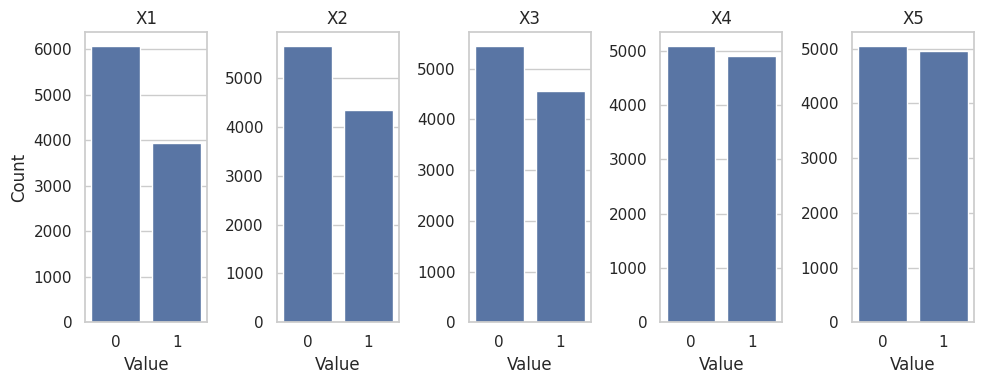

In [8]:
plt.figure(figsize=(10, 4))

for i, col in enumerate(df.columns):
    plt.subplot(1, 5, i+1)
    counts = df[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(col)
    plt.xlabel("Value")
    plt.ylabel("Count" if i == 0 else "")

plt.tight_layout()
plt.show()


In [9]:
# Group by X1 and compute mean of X5 (since it's 0/1, mean = probability of 1)
cond_probs = df.groupby("X1")["X5"].mean()
cond_probs


X1
0    0.371499
1    0.687277
Name: X5, dtype: float64

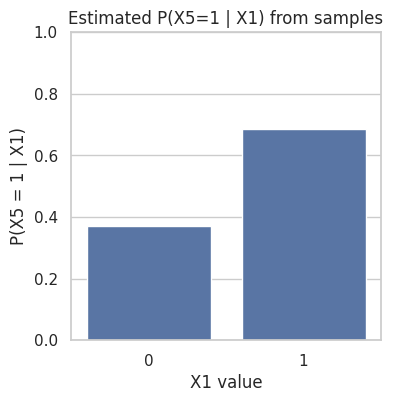

In [10]:
plt.figure(figsize=(4, 4))
sns.barplot(x=cond_probs.index.astype(str), y=cond_probs.values)
plt.xlabel("X1 value")
plt.ylabel("P(X5 = 1 | X1)")
plt.title("Estimated P(X5=1 | X1) from samples")
plt.ylim(0, 1)
plt.show()


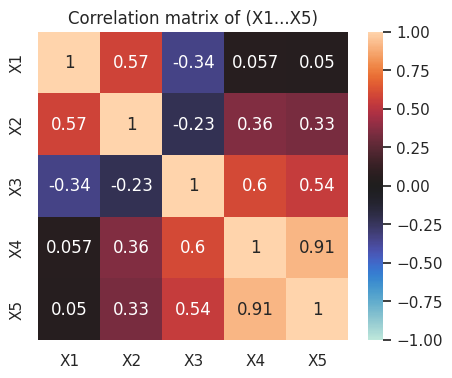

In [18]:
plt.figure(figsize=(5, 4))
corr = df.corr()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, center=0)
plt.title("Correlation matrix of (X1...X5)")
plt.show()


## Linear Gaussian Bayesian Network

All random variables are continuous Gaussians.

Factorization:

$$
p(x_1,x_2,x_3,x_4,x_5)
= p(x_1)\,p(x_2\mid x_1)\,p(x_3\mid x_1)\,p(x_4\mid x_2,x_3)\,p(x_5\mid x_4).
$$

### Root Node

$$
X_1 \sim \mathcal{N}(0,\,1)
$$

### Conditional Distributions

$$
X_2 \mid X_1 \sim 
\mathcal{N}(0.5\,X_1,\; 0.5)
$$

$$
X_3 \mid X_1 \sim
\mathcal{N}(-0.3\,X_1,\; 0.7)
$$

$$
X_4 \mid X_2, X_3 \sim
\mathcal{N}(0.6\,X_2 + 0.8\,X_3,\; 0.4)
$$

$$
X_5 \mid X_4 \sim
\mathcal{N}(1.2\,X_4,\; 0.3)
$$


In [12]:
def sample_gaussian_bn(n_samples=1000, rng=None):
    """
    Gaussian Bayesian network with DAG:
    1 -> 2, 1 -> 3, 2 -> 4, 3 -> 4, 4 -> 5
    
    Returns:
        DataFrame with columns ['X1','X2','X3','X4','X5']
    """
    if rng is None:
        rng = np.random.default_rng()
        
    X = np.zeros((n_samples, 5), dtype=float)
    
    # X1 ~ N(0, 1)
    X[:, 0] = rng.normal(loc=0, scale=1, size=n_samples)

    # X2 | X1 ~ N(0.5*X1, 0.5)
    X[:, 1] = rng.normal(loc=0.5 * X[:, 0], scale=np.sqrt(0.5))

    # X3 | X1 ~ N(-0.3*X1, 0.7)
    X[:, 2] = rng.normal(loc=-0.3 * X[:, 0], scale=np.sqrt(0.7))

    # X4 | X2, X3 ~ N(0.6*X2 + 0.8*X3, 0.4)
    mean4 = 0.6 * X[:, 1] + 0.8 * X[:, 2]
    X[:, 3] = rng.normal(loc=mean4, scale=np.sqrt(0.4))

    # X5 | X4 ~ N(1.2*X4, 0.3)
    X[:, 4] = rng.normal(loc=1.2 * X[:, 3], scale=np.sqrt(0.3))
    
    return pd.DataFrame(X, columns=["X1","X2","X3","X4","X5"])


In [13]:
df = sample_gaussian_bn(5000)
df.head()


,X1,X2,X3,X4,X5
0,-0.469963,-1.298305,-0.260128,-1.030382,-0.855027
1,-0.074594,-0.349978,0.231659,0.347330,0.183078
2,0.059175,0.925056,0.525984,0.813671,0.302537
3,-0.206398,-0.254389,0.708236,-0.739022,-0.229203
4,-0.708556,-0.188118,-0.257136,-0.454381,-0.497639


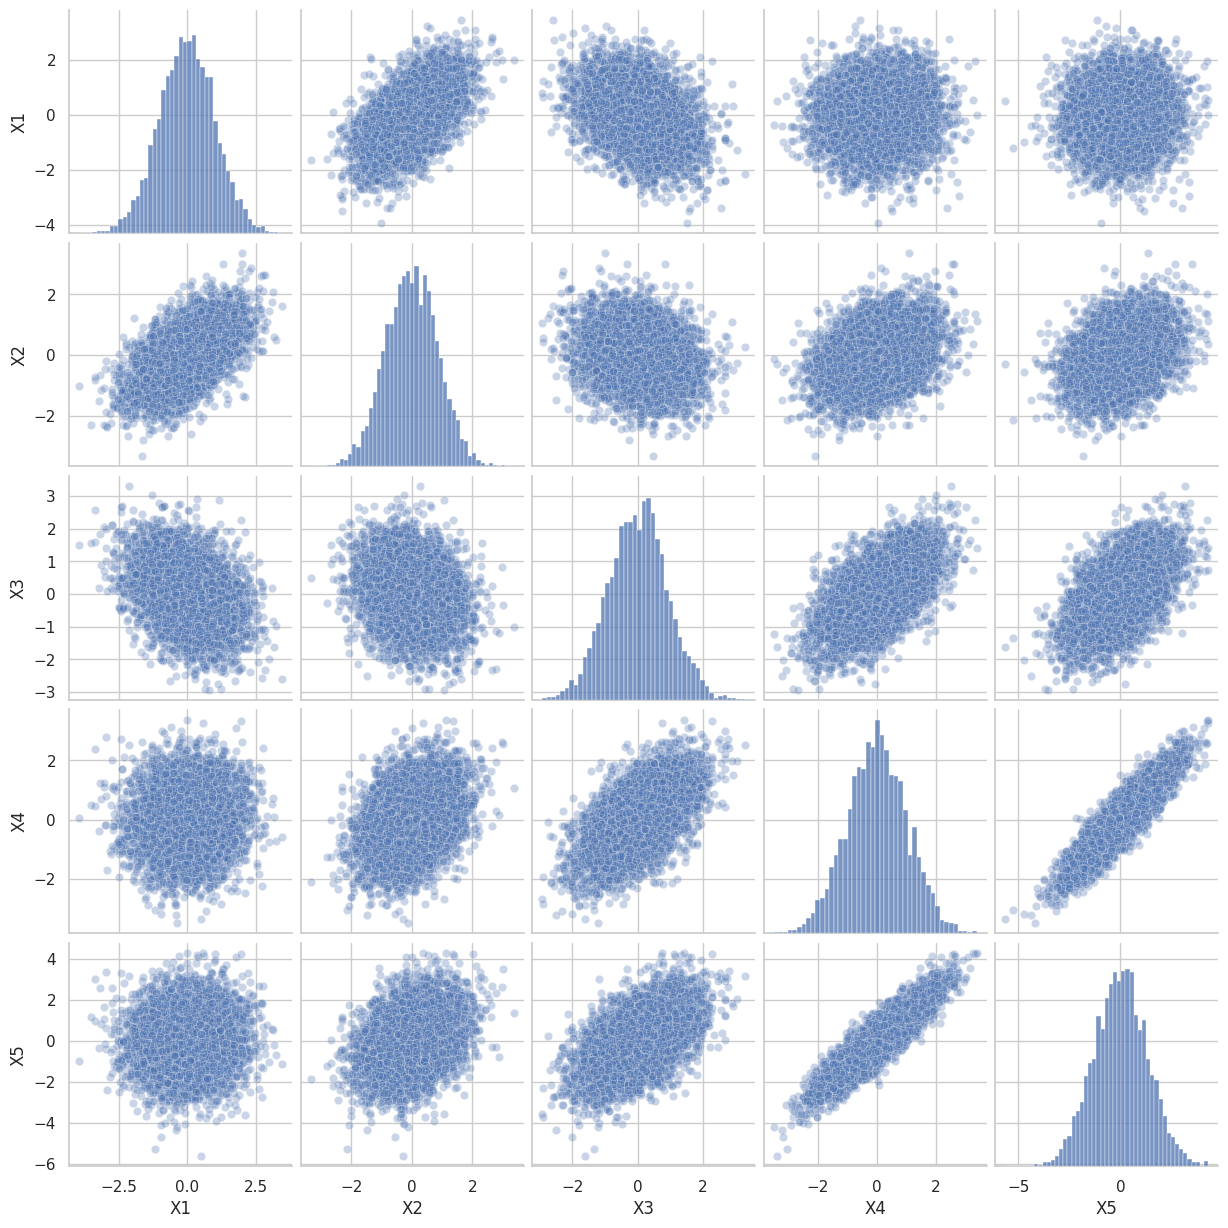

In [14]:
sns.pairplot(df, plot_kws={'alpha':0.3})
plt.show()


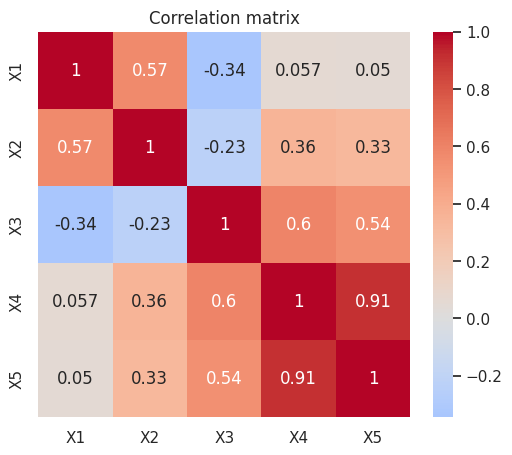

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()


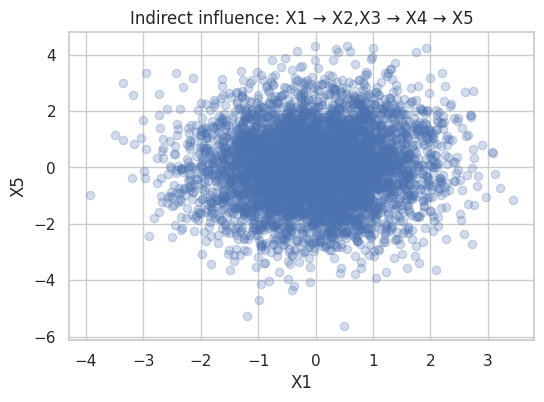

In [16]:
plt.figure(figsize=(6,4))
plt.scatter(df["X1"], df["X5"], alpha=0.25)
plt.xlabel("X1")
plt.ylabel("X5")
plt.title("Indirect influence: X1 → X2,X3 → X4 → X5")
plt.show()


In [23]:
import scipy.stats
scipy.stats.pearsonr(df["X1"], df["X5"])

PearsonRResult(statistic=np.float64(0.05039652729334036), pvalue=np.float64(0.00036392984265558645))